# Batching raw ultrasound data with `zea.Dataloader`

`zea.Dataloader` turns a folder of zea files into a batched, shuffled, multi-threaded stream of
samples, ready for a training loop. It is built on [Grain](https://github.com/google/grain).

Most dataloader examples use images, but channel data (`raw_data`) is where the loader earns its
keep: the arrays are five-dimensional and large, so *what* you read matters as much as how fast
you read it. This notebook covers:

1. Building a small `raw_data` dataset to load from
2. Batching raw channel data
3. Reading only the transmits you need with `axis_selections`
4. Grouping consecutive frames into temporal blocks
5. Getting file metadata — scan parameters, probe geometry, subject, annotations — back with each
   batch via `return_metadata`
6. Selecting files by their content with `file_filter`
7. Beamforming a batch using the metadata the loader handed you

See the [zea data format notebook](zea_data_example.ipynb) for `zea.File` and `zea.Dataset`, which
this notebook builds on.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_dataloader_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_dataloader_example.ipynb)
&nbsp;
[![Hugging Face dataset](https://img.shields.io/badge/Hugging%20Face-Dataset-yellow?logo=huggingface)](https://huggingface.co/datasets/zeahub/phantoms)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
source_path = "hf://zeahub/phantoms/2025_05_19_cirs_planewave.hdf5"
dataset_dir = "phantom-dataset"
n_files = 5

In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [4]:
import shutil
import time
from pathlib import Path

import keras
import numpy as np

import zea
from zea.ops import (
    Beamform,
    Demodulate,
    Downsample,
    EnvelopeDetect,
    LogCompress,
    Normalize,
    Pipeline,
)
from zea.visualize import plot_image_grid, set_mpl_style

zea: Using backend 'jax'


In [5]:
zea.init_device(verbose=False)
set_mpl_style()

## 1. A small `raw_data` dataset

Real channel-data datasets are enormous — a single file of the
[TU/e carotid dataset](https://huggingface.co/datasets/zeahub/zea-carotid-2023) is over 5 GB,
because `raw_data` has shape `(n_frames, n_tx, n_ax, n_el, n_ch)`: every frame stores the full
receive aperture for every transmit event. Downloading one of those to demonstrate a dataloader
would be unkind, so we take a single 43 MB CIRS phantom acquisition and split it into a handful of
files. That gives us a real multi-file dataset that fits in a notebook.

In [6]:
with zea.File(source_path) as file:
    raw_data = file.data.raw_data[:]
    scan = file.get_scan_parameters()
    probe = {key: value for key, value in file.probe.to_dict().items() if value is not None}

n_frames, n_tx, n_ax, n_el, n_ch = raw_data.shape
print(f"{n_frames} frames, {n_tx} transmits, {n_ax} axial samples, {n_el} elements, {n_ch} channel")
print("dtype:", raw_data.dtype)

10 frames, 21 transmits, 2432 axial samples, 128 elements, 1 channel
dtype: int16


We write the frames out over `n_files` files with `zea.File.create`, attaching the metadata we
want to load later: a subject, per-frame image quality annotations, and the acquisition's own scan
and probe groups. Note that `time_to_next_transmit` has shape `(n_frames, n_tx)`, so it is sliced
per file along with the data — the dataloader will later slice it again, per sample.

In [7]:
dataset_dir = Path(dataset_dir)
shutil.rmtree(dataset_dir, ignore_errors=True)
dataset_dir.mkdir(parents=True)

n_frames_per_file = n_frames // n_files
quality_per_frame = ["high", "low"]  # one label per frame, within each file

for i in range(n_files):
    frames = slice(i * n_frames_per_file, (i + 1) * n_frames_per_file)
    zea.File.create(
        dataset_dir / f"phantom_{i}_0000.hdf5",
        data={"raw_data": raw_data[frames]},
        scan={**scan, "time_to_next_transmit": scan["time_to_next_transmit"][frames]},
        probe=probe,
        metadata={
            "subject": {"id": f"cirs-{i}", "type": "phantom"},
            "annotations": {
                "anatomy": "phantom",
                "image_quality": np.array(quality_per_frame, dtype=np.str_),
            },
        },
        description="CIRS phantom plane-wave acquisition, split for this tutorial",
        us_machine="Verasonics Vantage 256",
        overwrite=True,
        warn_missing_optional_fields=False,
    )

total_mb = sum(path.stat().st_size for path in dataset_dir.glob("*.hdf5")) / 1e6
print(f"{n_files} files, {total_mb:.0f} MB total in {dataset_dir}/")

zea: File saved to phantom-dataset/phantom_0_0000.hdf5


zea: File saved to phantom-dataset/phantom_1_0000.hdf5


zea: File saved to phantom-dataset/phantom_2_0000.hdf5


zea: File saved to phantom-dataset/phantom_3_0000.hdf5


zea: File saved to phantom-dataset/phantom_4_0000.hdf5


5 files, 45 MB total in phantom-dataset/


## 2. Batching raw channel data

Point the loader at the folder and give it the key to read. Two arguments deserve attention for
raw data:

- **`key="data/raw_data"`** instead of the image default `"data/image/values"`.
- **`insert_frame_axis=False`** — by default the loader moves the frame axis to `frame_axis=-1`,
  which suits `(height, width)` images but would scramble the `(n_tx, n_ax, n_el, n_ch)` layout the
  processing pipeline expects. With `insert_frame_axis=False` and `n_frames=1` each sample keeps
  its natural raw-data shape.

The image-specific arguments (`image_size`, `image_range`, `normalization_range`, `resize_type`)
are no-ops here — leave them unset for channel data.

In [8]:
loader = zea.Dataloader(
    dataset_dir,
    key="data/raw_data",
    batch_size=2,
    n_frames=1,
    insert_frame_axis=False,
    shuffle=False,
)

print("batches:", len(loader))
print("batch shape:", loader.shape)

batch = next(iter(loader))
print("first batch:", batch.shape, batch.dtype)
loader.close()

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Dataset validated. Check phantom-dataset/validated.flag for details.


zea: Running _find_h5_file_shapes and caching the result to /zea/.cache/zea/cached_funcs/_find_h5_file_shapes_d08fef72a1e6959b076ffbdba4688025.pkl.


batches: 5
batch shape: (2, 21, 2432, 128, 1)
first batch: (2, 21, 2432, 128, 1) float32


Each sample is one frame with all 21 transmits, and the loader casts it to `float32`. Note that
the loader counts *frames*, not files: five files of two frames each give ten samples, which at
`batch_size=2` is the five batches reported by `len(loader)`.

## 3. Reading only the transmits you need

A full frame of channel data is `21 × 2432 × 128` samples. If your model only needs a few transmit
events, `axis_selections` applies the selection **at HDF5 read time**, so the unused data is never
read into memory:

In [9]:
def time_one_epoch(**kwargs):
    loader = zea.Dataloader(
        dataset_dir,
        key="data/raw_data",
        batch_size=2,
        n_frames=1,
        insert_frame_axis=False,
        shuffle=False,
        validate=False,
        **kwargs,
    )
    for _ in loader:  # warm up the file handles
        pass
    start = time.perf_counter()
    for _ in loader:
        pass
    elapsed = time.perf_counter() - start
    shape = loader.shape
    loader.close()
    return shape, elapsed


for label, kwargs in [
    ("all 21 transmits", {}),
    ("transmits 0-2", {"axis_selections": {1: [0, 1, 2]}}),
    ("transmits 0, 10, 20", {"axis_selections": {1: [0, 10, 20]}}),
]:
    shape, elapsed = time_one_epoch(**kwargs)
    print(f"{label:20s} {str(shape):26s} {elapsed * 1e3:6.0f} ms/epoch")

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Loading cached result for _find_h5_file_shapes.


all 21 transmits     (2, 21, 2432, 128, 1)          96 ms/epoch
zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Loading cached result for _find_h5_file_shapes.


transmits 0-2        (2, 3, 2432, 128, 1)           30 ms/epoch
zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Loading cached result for _find_h5_file_shapes.


transmits 0, 10, 20  (2, 3, 2432, 128, 1)           32 ms/epoch


The axis keys are axes of the array **as stored in the file**, so axis `1` is the transmit axis
of `(n_frames, n_tx, n_ax, n_el, n_ch)`. Three of 21 transmits load several times faster, whether
they are neighbours or spread across the aperture.

What the selection costs is set by the **chunks** it touches, not by how many indices you asked
for. `raw_data` here is chunked 13 transmits at a time, so transmits 0-2 sit in one chunk while
0, 10 and 20 straddle both — hence the small gap between the last two rows. The rule of thumb: a
selection confined to a few chunks saves time as well as memory; one that touches every chunk still
saves memory, but reads about as much as the full axis.

Reads go through zea's concurrent chunk reader
([`zea.data.chunk_reader`](../../_autosummary/zea.data.chunk_reader.rst)), which fetches the chunk
byte ranges itself and decodes them in parallel, rather than h5py's serial one-chunk-at-a-time
path.

## 4. Temporal blocks

Set `n_frames > 1` to get blocks of consecutive frames per sample — useful for models that see
short sequences. For raw data, put the frame axis first with `frame_axis=0` so samples keep the
`(n_frames, n_tx, n_ax, n_el, n_ch)` layout of the file. `frame_index_stride` subsamples within a
block, and `overlapping_blocks=True` slides the block by one frame instead of `n_frames`.

In [10]:
loader = zea.Dataloader(
    dataset_dir,
    key="data/raw_data",
    batch_size=None,  # no batching: one sample at a time
    n_frames=2,
    frame_axis=0,
    axis_selections={1: [0, 1, 2]},
    shuffle=False,
)

print("blocks:", len(loader))
print("sample shape:", loader.shape)
loader.close()

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Dataset was validated on August 19, 2026


zea: Remove phantom-dataset/validated.flag if you want to redo validation.


zea: Loading cached result for _find_h5_file_shapes.


blocks: 5
sample shape: (2, 3, 2432, 128, 1)


## 5. Getting metadata back with the batch

A zea file carries much more than its data array. `return_metadata` asks the loader to return a
`(sample, metadata)` tuple instead of a bare array. With `return_metadata=True` you get just the
identity of the sample: which file it came from and which indices were read.

In [11]:
loader = zea.Dataloader(
    dataset_dir,
    key="data/raw_data",
    batch_size=None,
    n_frames=1,
    insert_frame_axis=False,
    shuffle=False,
    return_metadata=True,
)

sample, metadata = next(iter(loader))
print(metadata["file"]["filename"])
print(metadata["file"]["indices"])
loader.close()

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Dataset was validated on August 19, 2026


zea: Remove phantom-dataset/validated.flag if you want to redo validation.


zea: Loading cached result for _find_h5_file_shapes.


phantom_4_0000
(slice(0, 1, 1), slice(None, 21, None), slice(None, 2432, None), slice(None, 128, None), slice(None, 1, None))


To load actual file metadata, pass a list of **dotted paths** — the same path syntax used by
`file_filter` below. A path may point at a single field (`"scan.sound_speed"`) or at a whole group
(`"metadata.subject"`), in which case everything below it is loaded.

The result mirrors the [zea file spec](../../_autosummary/zea.data.spec.rst): `scan`, `probe`,
`metadata`, `metrics` and friends appear at the top level, with the loader's own bookkeeping
tucked under `"file"`.

In [12]:
loader = zea.Dataloader(
    dataset_dir,
    key="data/raw_data",
    batch_size=None,
    n_frames=1,
    insert_frame_axis=False,
    shuffle=False,
    return_metadata=[
        "metadata.subject",
        "metadata.annotations",
        "scan.sound_speed",
        "scan.time_to_next_transmit",
        "probe.probe_geometry",
        "us_machine",
    ],
)

sample, metadata = next(iter(loader))


def print_tree(tree, indent=""):
    for key, value in tree.items():
        if isinstance(value, dict):
            print(f"{indent}{key}/")
            print_tree(value, indent + "  ")
        else:
            shape = getattr(value, "shape", ())
            print(f"{indent}{key}: {value if shape == () else f'{value.dtype} {shape}'}")


print_tree(metadata)

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Dataset was validated on August 19, 2026


zea: Remove phantom-dataset/validated.flag if you want to redo validation.


zea: Loading cached result for _find_h5_file_shapes.


metadata/
  subject/
    id: cirs-4
    type: phantom
  annotations/
    anatomy: phantom
    image_quality: <U4 (1,)
scan/
  sound_speed: 1540.0
  time_to_next_transmit: float32 (1, 21)
probe/
  probe_geometry: float32 (128, 3)
us_machine: Verasonics Vantage 256
file/
  fullpath: phantom-dataset/phantom_4_0000.hdf5
  filename: phantom_4_0000
  indices: (slice(0, 1, 1), slice(None, 21, None), slice(None, 2432, None), slice(None, 128, None), slice(None, 1, None))


Asking for paths rather than everything is what keeps this cheap. Each path is read straight off
the HDF5 group, so a large field you did not ask for (a long ECG trace, a segmentation map) is
never touched. On top of that the loader reads a file's metadata **once per file**, not once per
sample, and caches it — the cost is amortised over every sample drawn from that file.

### Per-frame metadata follows the frames

Some fields describe individual frames rather than the whole file. `image_quality` here has one
label per frame, and `time_to_next_transmit` has shape `(n_frames, n_tx)`. The loader recognises
these from the file spec and slices them with the same frame selection used for the data, so the
metadata always lines up with the frames you got. Fields without a frame axis — `anatomy`,
`sound_speed`, `probe_geometry` — are returned whole.

In [13]:
for sample, metadata in loader:
    annotations = metadata["metadata"]["annotations"]
    print(
        f"{metadata['file']['filename']}  "
        f"data={tuple(sample.shape)}  "
        f"image_quality={annotations['image_quality']}  "
        f"anatomy={annotations['anatomy']}  "
        f"time_to_next_transmit={metadata['scan']['time_to_next_transmit'].shape}"
    )
loader.close()

phantom_4_0000  data=(21, 2432, 128, 1)  image_quality=['high']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_4_0000  data=(21, 2432, 128, 1)  image_quality=['low']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_3_0000  data=(21, 2432, 128, 1)  image_quality=['high']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_3_0000  data=(21, 2432, 128, 1)  image_quality=['low']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_1_0000  data=(21, 2432, 128, 1)  image_quality=['high']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_1_0000  data=(21, 2432, 128, 1)  image_quality=['low']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_2_0000  data=(21, 2432, 128, 1)  image_quality=['high']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_2_0000  data=(21, 2432, 128, 1)  image_quality=['low']  anatomy=phantom  time_to_next_transmit=(1, 21)
phantom_0_0000  data=(21, 2432, 128, 1)  image_quality=['high']  anatomy=phantom  time_to_next_transmit=(1, 

Two frames per file, and each one comes back with its own quality label and its own row of
transmit timings.

> **Note:** when batching is on, metadata is stacked leaf by leaf just like the data, so every file
> must supply the same fields with the same shapes. If your metadata varies in shape between files,
> use `batch_size=None` and batch it yourself.

## 6. Selecting files by their content

`file_filter` drops files before any frames are indexed. It takes either a callable
`File -> bool`, or a dict of dotted paths to conditions — a plain value for equality, a callable
for anything else, or the `EXISTS` helper to require that a field is present at all. All entries
are ANDed.

In [14]:
loader = zea.Dataloader(
    dataset_dir,
    key="data/raw_data",
    batch_size=None,
    n_frames=1,
    insert_frame_axis=False,
    shuffle=False,
    file_filter={
        "metadata.subject.type": "phantom",
        "metadata.subject.id": lambda value: value in ("cirs-0", "cirs-2"),
    },
    return_metadata=["metadata.subject.id"],
)

print("samples after filtering:", len(loader))
print([metadata["metadata"]["subject"]["id"] for _, metadata in loader])
loader.close()

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Dataset was validated on August 19, 2026


zea: Remove phantom-dataset/validated.flag if you want to redo validation.


zea: DEBUG file_filter excluded 'phantom-dataset/phantom_4_0000.hdf5'.


zea: DEBUG file_filter excluded 'phantom-dataset/phantom_3_0000.hdf5'.


zea: DEBUG file_filter excluded 'phantom-dataset/phantom_1_0000.hdf5'.


zea: file_filter kept 2/5 files (3 removed).


zea: Running _find_h5_file_shapes and caching the result to /zea/.cache/zea/cached_funcs/_find_h5_file_shapes_50b7da268f05e9ffb4a8fbf6ec7e8acf.pkl.


samples after filtering: 4
['cirs-2', 'cirs-2', 'cirs-0', 'cirs-0']


## 7. Beamforming a batch with its own metadata

Here is where returning metadata pays off. To process channel data you need the acquisition
parameters — sampling frequency, transmit delays, probe geometry — and without them in the batch
you would have to reopen each file to look them up. Asking for the `scan` and `probe` groups gives
you everything `zea.Parameters` needs, straight from the loader.

Because these files share one acquisition, we take the first element of the batched metadata. The
`name` and `type` probe fields are labels rather than parameters, so we drop them.

In [15]:
loader = zea.Dataloader(
    dataset_dir,
    key="data/raw_data",
    batch_size=4,
    n_frames=1,
    insert_frame_axis=False,
    shuffle=False,
    return_metadata=["scan", "probe", "metadata.subject.id", "metadata.annotations.image_quality"],
)

batch, metadata = next(iter(loader))
batch = keras.ops.convert_to_numpy(batch)

scan = {key: value[0] for key, value in metadata["scan"].items()}
probe = {key: value[0] for key, value in metadata["probe"].items() if key not in ("name", "type")}

parameters = zea.Parameters(
    **scan,
    **probe,
    n_ax=batch.shape[2],
    n_el=batch.shape[3],
    n_tx=batch.shape[1],
    xlims=(-0.019, 0.019),
    zlims=(0.005, 0.055),
)
print(f"batch {batch.shape}, sound speed {parameters.sound_speed} m/s, {parameters.n_tx} transmits")

zea: Searching phantom-dataset for ['.hdf5', '.h5'] files...


zea: Dataset was validated on August 19, 2026


zea: Remove phantom-dataset/validated.flag if you want to redo validation.


zea: Loading cached result for _find_h5_file_shapes.


batch (4, 21, 2432, 128, 1), sound speed 1540.0 m/s, 21 transmits


Now a standard plane-wave pipeline. See the [pipeline notebook](../pipeline/zea_pipeline_example.ipynb)
for what each operation does. We use `with_batch_dim=True` so the whole batch is processed at
once.

In [16]:
pipeline = Pipeline(
    operations=[
        Demodulate(),
        Downsample(factor=4),
        Beamform(beamformer="delay_and_sum", enable_pfield=False, num_patches=200),
        EnvelopeDetect(),
        Normalize(),
        LogCompress(),
    ],
    with_batch_dim=True,
    jit_options="pipeline",
)

images = pipeline(data=batch, **pipeline.prepare_parameters(parameters))["data"]
images = keras.ops.convert_to_numpy(images)
print("images:", images.shape)

images: (4, 1015, 772)


Finally we plot the batch, titling each image with the metadata that arrived alongside it.

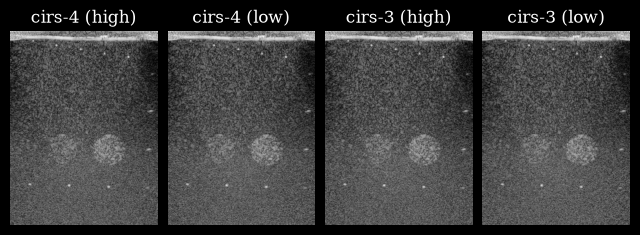

In [17]:
titles = [
    f"{subject_id} ({quality})"
    for subject_id, quality in zip(
        metadata["metadata"]["subject"]["id"],
        metadata["metadata"]["annotations"]["image_quality"].squeeze(-1),
    )
]

fig, _ = plot_image_grid(images, ncols=4, cmap="gray", vmin=-50, vmax=0, titles=titles)
loader.close()

## Summary

- Use `key="data/raw_data"` with `insert_frame_axis=False` (or `frame_axis=0` for blocks) to keep
  channel data in its natural layout.
- `axis_selections` filters axes at HDF5 read time. It always saves memory; whether it saves time
  depends on the file's chunking.
- `n_frames`, `frame_index_stride` and `overlapping_blocks` build temporal blocks out of
  consecutive frames.
- `return_metadata` returns a `(sample, metadata)` tuple. `True` gives the file identity; a list of
  dotted paths adds fields from the file, shaped like the zea file spec with the loader's
  bookkeeping under `"file"`. Metadata is read once per file, and per-frame fields are sliced to
  match the sample.
- `file_filter` drops whole files by their content before indexing.

See the [`Dataloader` API reference](../../_autosummary/zea.data.dataloader.rst) for the full set of
arguments.

In [18]:
shutil.rmtree(dataset_dir, ignore_errors=True)